<a href="https://colab.research.google.com/github/rheopy/rheolite/blob/main/content/caber/caber_quickstart.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# 🎥 CaBER quickstart — Newtonian filament thinning

Video → filament neck radius vs time → thinning analysis, in your browser. We use **rheopy-caber** on a **6000 cP viscosity-standard oil** (Newtonian) filament thinning to breakup, recorded at 100 fps.

**Run each cell in order** (▶). The first cell installs `rheopy-caber` in your browser — no server involved. The test clip `test_clip.mp4` sits right next to this notebook; on Colab it is fetched from its public URL instead.


In [3]:
%pip install -q rheopy-caber ipywidgets pillow


Note: you may need to restart the kernel to use updated packages.


c:\Users\caggioni.m\rheolite\.venv\Scripts\python.exe: No module named pip


In [6]:
import os
import caber
from caber.data import test_clip_path, TEST_CLIP_FPS
from caber.io import open_video

# In JupyterLite the clip is bundled next to this notebook;
# anywhere else (Colab, desktop) it downloads once and caches.
clip = "test_clip.mp4" if os.path.exists("test_clip.mp4") else test_clip_path()
cap, info = open_video(clip)
print(f"{info.n_frames} frames, {info.width}x{info.height}")
print(f"true acquisition rate: {TEST_CLIP_FPS:.0f} fps (from the camera overlay timestamps)")
cap.release()

clip="6000cp_viscosity_standard.mp4"

131 frames, 310x226
true acquisition rate: 100 fps (from the camera overlay timestamps)


## Interactive ROI definition

Tune the region of interest, threshold, polarity and filament axis on one frame, then press **Run Full Analysis** to measure the whole video.


In [7]:
from caber.widgets import CaberVideo
viewer = CaberVideo(clip, fps=TEST_CLIP_FPS)
viewer


CaberVideo(children=(IntSlider(value=0, continuous_update=False, description='Frame:', max=467), HBox(children…

## Headless measurement — video → neck vs time


 frame  time_s  neck_px
     0    0.00      163
     1    0.01      166
     2    0.02      165
breakup at frame 313


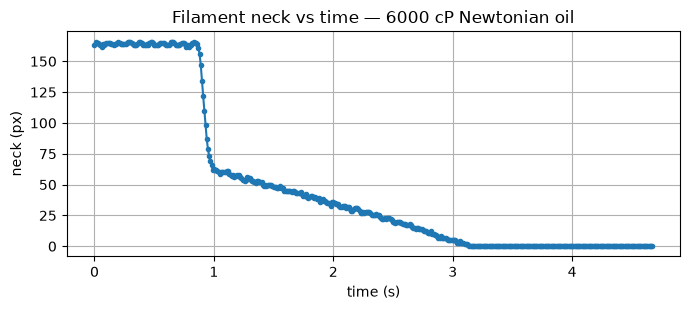

In [8]:
import matplotlib.pyplot as plt

df = caber.measure_video(clip, threshold=100, polarity="dark",
                         axis="horizontal", fps=TEST_CLIP_FPS)
print(df.head(3).to_string(index=False))
print(f"breakup at frame {caber.find_breakup(df)}")

plt.figure(figsize=(7, 3.2))
plt.plot(df.time_s, df.neck_px, marker="o", markersize=3)
plt.xlabel("time (s)"); plt.ylabel("neck (px)"); plt.grid(True)
plt.title("Filament neck vs time — 6000 cP Newtonian oil")
plt.tight_layout(); plt.show()


## Newtonian thinning analysis

Close to breakup a Newtonian filament thins linearly ($R(t) = 0.0709\cdot(\sigma/\eta)\cdot(t_c - t)$, Papageorgiou 1995), so the thinning slope gives the viscosity once the surface tension is known.

> ⚠️ Calibration honesty: the 6 mm / 456 px target in the source recording belongs to the *wide-view* regime (0.01316 mm/px); this clip is a 2×-downsampled excerpt of the *zoomed* regime, whose scale is not independently established. Treat the viscosity below as illustrative of the method.


slope dR/dt = -0.3335 mm/s, R^2 = 0.9094
breakup time t_c = 3.191 s
Newtonian viscosity ≈ 4.47 Pa·s


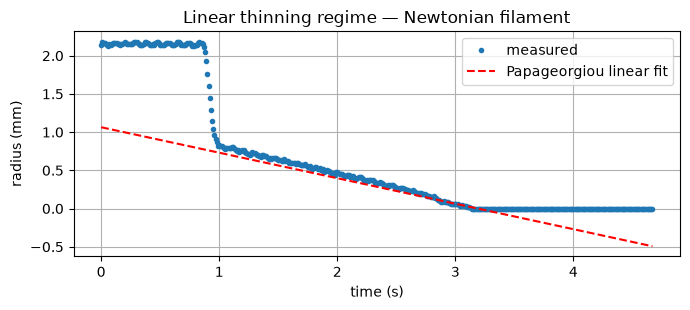

In [9]:
MM_PER_PX = 0.01316 * 2  # wide-view calibration x clip downsample

summary = caber.thinning_summary(df, mm_per_px=MM_PER_PX,
                                 surface_tension_mN_per_m=21.0)
rdf, fit = summary["df"], summary["fit"]
print(f"slope dR/dt = {fit['slope']:.4f} mm/s, R^2 = {fit['r_squared']:.4f}")
print(f"breakup time t_c = {fit['t_c']:.3f} s")
print(f"Newtonian viscosity ≈ {summary['viscosity_Pa_s']:.2f} Pa·s")

plt.figure(figsize=(7, 3.2))
plt.plot(rdf.time_s, rdf.radius_mm, "o", markersize=3, label="measured")
t = rdf.time_s
plt.plot(t, fit["intercept"] + fit["slope"]*t, "r--", label="Papageorgiou linear fit")
plt.xlabel("time (s)"); plt.ylabel("radius (mm)"); plt.grid(True); plt.legend()
plt.title("Linear thinning regime — Newtonian filament")
plt.tight_layout(); plt.show()
